# FRED_data_by_FDR_v2
FRED 데이터 수집 → investar 적재 → DB에서 읽어 분석

**저장 테이블 (investar, 표준 규격 STD-1)**

| 테이블 | 내용 | 키 |
|---|---|---|
| `us_fred_series_info` | 시리즈 설명표 (이름, 주기, 단위, 계절조정, FRED 최종 갱신일) | series_id |
| `us_fred_data` | 관측값 최신본 (시리즈 x 기간 1행) | series_id, period_end |
| `us_fred_data_vintage` | 값이 처음 들어오거나 바뀐 이력 + ALFRED 공표 이력 | id |

**STD-1 요약**: 소문자 snake_case 테이블명 / utf8mb4_general_ci / 기간은 `period_end`(기간 말일) + `freq`(D,W,M,Q,S,Y) /
수집 시각 `first_collected_at`, `last_collected_at`(KST) / 값 변경 이력은 `_vintage` 테이블에 append /
시계열형 데이터의 단위와 통화는 설명표(`_series_info`)에 둔다.

**사용 순서**: 1~4번 셀 실행 → 5번 수집·적재 → (처음 한 번) 6번 ALFRED 이력 → 7번 검증 → 8번 분석

## 1. 설정 및 접속

In [28]:
import sys
from pathlib import Path
from datetime import date, datetime, timedelta, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import text
from fredapi import Fred


def setup_universal_paths():
    """현재 폴더에서 상위로 올라가며 DATA 폴더를 찾아 sys.path에 추가."""
    for parent in [Path.cwd(), *Path.cwd().parents]:
        data_folder = parent / "DATA"
        if data_folder.exists():
            for p in (str(parent), str(data_folder)):
                if p not in sys.path:
                    sys.path.insert(0, p)
            print("프로젝트 루트:", parent)
            return parent
    raise FileNotFoundError("DATA 폴더를 찾지 못했습니다. investment_strategy 아래에서 실행하세요.")


ROOT = setup_universal_paths()

from DATA.KEYS import KEYS
import config

engine = config.get_engine(config.get_db_info())
fred = Fred(api_key=KEYS["FRED"])

OBS_START = "2000-01-01"          # 수집 시작일
KST = timezone(timedelta(hours=9))

T_INFO = "us_fred_series_info"
T_DATA = "us_fred_data"
T_VIN = "us_fred_data_vintage"
print("DB 엔진, FRED 클라이언트 준비 완료")

프로젝트 루트: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
DB 엔진, FRED 클라이언트 준비 완료


## 2. 수집 대상 시리즈 등록표
새 시리즈는 여기에 한 줄 추가하면 됩니다. `alias`는 분석용 짧은 이름, `group`은 묶음 이름입니다.

In [29]:
SERIES = {
    # ---- 기존: 반도체 사이클 ----
    "CAPUTLG3344S" : ("capacity_utilization",  "semiconductor_cycle"),
    "IPG3344S"     : ("industrial_production", "semiconductor_cycle"),
    "A34SNO"       : ("new_orders",            "semiconductor_cycle"),
    "A34SVS"       : ("shipments",             "semiconductor_cycle"),
    "PCU33443344"  : ("ppi_semiconductor",     "semiconductor_cycle"),

    # ---- 시장 위험 / 금융 여건 ----
    "VIXCLS"       : ("vix",                   "market_risk"),   # 일별
    "BAMLH0A0HYM2" : ("hy_spread",             "market_risk"),   # 하이일드 스프레드, 일별
    "BAA10Y"       : ("baa_spread",            "market_risk"),   # Baa - 10년물, 일별
    "NFCI"         : ("chicago_fci",           "market_risk"),   # 금융여건지수, 주별
    "STLFSI4"      : ("stl_stress",            "market_risk"),   # 금융스트레스지수, 주별

    # ---- 금리 ----
    "DFF"          : ("fed_funds",             "rates"),         # 일별
    "DGS2"         : ("ust_2y",                "rates"),
    "DGS10"        : ("ust_10y",               "rates"),
    "T10Y3M"       : ("term_spread_10y3m",     "rates"),         # 경기침체 신호로 많이 씀
    "DFII10"       : ("real_10y",              "rates"),         # 10년 실질금리
    "T10YIE"       : ("breakeven_10y",         "rates"),         # 10년 기대인플레

    # ---- 경기 / 수요 ----
    "INDPRO"       : ("ip_total",              "growth"),
    "NEWORDER"     : ("core_capex_orders",     "growth"),        # 항공기 제외 비국방 자본재 수주
    "RSAFS"        : ("retail_sales",          "growth"),
    "PAYEMS"       : ("nonfarm_payrolls",      "growth"),
    "UNRATE"       : ("unemployment",          "growth"),
    "ICSA"         : ("initial_claims",        "growth"),        # 주별
    "UMCSENT"      : ("consumer_sentiment",    "growth"),
    "GDPC1"        : ("real_gdp",              "growth"),        # 분기

    # ---- 물가 ----
    "CPIAUCSL"     : ("cpi",                   "inflation"),
    "CPILFESL"     : ("core_cpi",              "inflation"),
    "PCEPILFE"     : ("core_pce",              "inflation"),

    # ---- 원자재 / 환율 ----
    "DCOILWTICO"   : ("wti",                   "commodity"),     # 일별
    "PCOPPUSDM"    : ("copper",                "commodity"),     # 월별
    "DTWEXBGS"     : ("dollar_index_broad",    "fx"),            # 일별
    "DEXKOUS"      : ("usdkrw",                "fx"),            # 일별

        # ---- 소비 동향 ----
    # 개인소비지출 (월별)
    "PCE"          : ("pce",                    "consumption"),   # 명목 개인소비지출
    "PCEC96"       : ("real_pce",               "consumption"),   # 실질 개인소비지출
    "PCEDG"        : ("pce_durable",            "consumption"),   # 내구재
    "PCEND"        : ("pce_nondurable",         "consumption"),   # 비내구재
    "PCES"         : ("pce_services",           "consumption"),   # 서비스

    # 소매판매 (월별)
    "RSAFS"        : ("retail_sales",           "consumption"),   # 소매+음식점 전체
    "RRSFS"        : ("real_retail_sales",      "consumption"),   # 실질 소매판매
    "RSFSXMV"      : ("retail_sales_ex_auto",   "consumption"),   # 자동차 제외
    "RSNSR"        : ("retail_nonstore",        "consumption"),   # 온라인 등 무점포
    "RSEAS"        : ("retail_electronics",     "consumption"),   # 전자제품·가전 매장
    "RSHPCS"       : ("retail_health_beauty",   "consumption"),   # 건강·뷰티 매장
    "RSCCAS"       : ("retail_clothing",        "consumption"),   # 의류 매장
    "ECOMSA"       : ("ecommerce_sales",        "consumption"),   # 전자상거래 매출 (분기)
    "TOTALSA"      : ("vehicle_sales",          "consumption"),   # 자동차 판매 (연율, 백만 대)

    # 소득·저축 (월별)
    "DSPIC96"      : ("real_disposable_income", "consumption"),   # 실질 가처분소득
    "PSAVERT"      : ("saving_rate",            "consumption"),   # 개인 저축률

    # 소비자 신용
    "TOTALSL"      : ("consumer_credit",        "consumption"),   # 소비자신용 잔액 (월별)
    "REVOLSL"      : ("revolving_credit",       "consumption"),   # 카드 등 회전신용 (월별)
    "DRCCLACBS"    : ("card_delinquency",       "consumption"),   # 카드대출 연체율 (분기)

    # 심리
    "UMCSENT"      : ("consumer_sentiment",     "consumption"),   # 미시간대 소비자심리

        # ---- 주택시장 ----
    # 공급 (월별)
    "HOUST"            : ("housing_starts",         "housing"),   # 주택 착공 전체
    "HOUST1F"          : ("housing_starts_single",  "housing"),   # 단독주택 착공
    "PERMIT"           : ("building_permits",       "housing"),   # 건축 허가 (착공 선행)
    "MSACSR"           : ("new_home_supply_months", "housing"),   # 신규주택 재고 개월 수

    # 판매 (월별)
    "HSN1F"            : ("new_home_sales",         "housing"),   # 신규 단독주택 판매

    # 가격
    "CSUSHPISA"        : ("case_shiller_national",  "housing"),   # 케이스-실러 전국 (월별)
    "USSTHPI"          : ("fhfa_hpi",               "housing"),   # FHFA 주택가격지수 (분기)
    "MSPUS"            : ("median_home_price",      "housing"),   # 주택 판매가 중위값 (분기)

    # 금리·부실
    "MORTGAGE30US"     : ("mortgage_30y",           "housing"),   # 30년 고정 모기지 금리 (주별)
    "DRSFRMACBS"       : ("mortgage_delinquency",   "housing"),   # 주택담보대출 연체율 (분기)

    # 임대
    "CUSR0000SEHA"     : ("cpi_rent",               "housing"),   # 소비자물가 중 임대료 (월별)
    "RRVRUSQ156N"      : ("rental_vacancy",         "housing"),   # 임대 공실률 (분기)

    # ---- 자동차 / 중고차 ----
    "CUSR0000SETA02"   : ("cpi_used_cars",          "auto"),      # 중고차 소비자물가 (월별)
    "CUSR0000SETA01"   : ("cpi_new_cars",           "auto"),      # 신차 소비자물가 (월별, 비교용)
    "MRTSSM44112USN"   : ("used_car_dealer_sales",  "auto"),      # 중고차 딜러 매출 (월별, 계절조정 없음)
    "MVLOAS"           : ("auto_loans",             "auto"),      # 자동차 대출 잔액 (분기)
    "RIFLPBCIANM60NM"  : ("auto_loan_rate_60m",     "auto"),      # 60개월 신차 대출 금리

}
print(f"등록 시리즈 {len(SERIES)}개")

등록 시리즈 66개


## 3. 테이블 생성 (없을 때만)

In [30]:
_OPTS = "ENGINE=InnoDB DEFAULT CHARSET=utf8mb4 COLLATE=utf8mb4_general_ci"

DDL = [
f"""
CREATE TABLE IF NOT EXISTS {T_INFO} (
    series_id           VARCHAR(50)  NOT NULL COMMENT 'FRED 시리즈 ID',
    alias               VARCHAR(50)  NULL     COMMENT '분석용 짧은 이름',
    series_group        VARCHAR(50)  NULL     COMMENT '묶음 이름',
    title               VARCHAR(255) NULL,
    freq                CHAR(1)      NOT NULL COMMENT 'D,W,M,Q,S,Y',
    freq_label          VARCHAR(50)  NULL     COMMENT 'FRED 원문 주기',
    units               VARCHAR(150) NULL     COMMENT 'FRED 원문 단위',
    unit                VARCHAR(50)  NULL     COMMENT 'FRED 약식 단위',
    currency            CHAR(3)      NULL     COMMENT 'ISO 4217, 금액 단위일 때만',
    seasonal_adjustment VARCHAR(10)  NULL     COMMENT 'SA, NSA, SAAR 등',
    obs_start           DATE         NULL,
    obs_end             DATE         NULL,
    fred_last_updated   DATETIME     NULL     COMMENT 'FRED 최종 갱신 시각(KST)',
    notes               TEXT         NULL,
    is_active           TINYINT      NOT NULL DEFAULT 1,
    first_collected_at  DATETIME     NOT NULL,
    last_collected_at   DATETIME     NOT NULL,
    created_at          TIMESTAMP    NOT NULL DEFAULT CURRENT_TIMESTAMP,
    updated_at          TIMESTAMP    NOT NULL DEFAULT CURRENT_TIMESTAMP ON UPDATE CURRENT_TIMESTAMP,
    PRIMARY KEY (series_id),
    KEY idx_group (series_group)
) {_OPTS} COMMENT='FRED 시리즈 설명표 (STD-1)'
""",
f"""
CREATE TABLE IF NOT EXISTS {T_DATA} (
    series_id          VARCHAR(50) NOT NULL,
    period_end         DATE        NOT NULL COMMENT '기간 말일',
    freq               CHAR(1)     NOT NULL,
    value              DOUBLE      NULL,
    first_release_date DATE        NULL     COMMENT '최초 공표일 (ALFRED 이력 적재 후 채워짐)',
    first_collected_at DATETIME    NOT NULL COMMENT '최초 관측 시각(KST)',
    last_collected_at  DATETIME    NOT NULL COMMENT '최근 관측 시각(KST)',
    created_at         TIMESTAMP   NOT NULL DEFAULT CURRENT_TIMESTAMP,
    updated_at         TIMESTAMP   NOT NULL DEFAULT CURRENT_TIMESTAMP ON UPDATE CURRENT_TIMESTAMP,
    PRIMARY KEY (series_id, period_end),
    KEY idx_period_end (period_end)
) {_OPTS} COMMENT='FRED 관측값 최신본 (STD-1)'
""",
f"""
CREATE TABLE IF NOT EXISTS {T_VIN} (
    id           BIGINT      NOT NULL AUTO_INCREMENT,
    series_id    VARCHAR(50) NOT NULL,
    period_end   DATE        NOT NULL,
    value        DOUBLE      NULL,
    release_date DATE        NULL     COMMENT 'FRED 공표일(realtime_start). 일반 수집분은 NULL',
    change_type  VARCHAR(10) NOT NULL COMMENT 'new | revised | alfred',
    collected_at DATETIME    NOT NULL COMMENT '이 값을 관측한 시각(KST)',
    created_at   TIMESTAMP   NOT NULL DEFAULT CURRENT_TIMESTAMP,
    PRIMARY KEY (id),
    UNIQUE KEY uk_release (series_id, period_end, release_date),
    KEY idx_key_time (series_id, period_end, collected_at)
) {_OPTS} COMMENT='FRED 관측값 이력 (STD-1 vintage)'
""",
]

with engine.begin() as cx:
    for ddl in DDL:
        cx.execute(text(ddl))
print("테이블 준비 완료:", T_INFO, T_DATA, T_VIN)

테이블 준비 완료: us_fred_series_info us_fred_data us_fred_data_vintage


## 4. 수집·적재 함수

In [31]:
FREQ_MAP = {"D": "D", "W": "W", "BW": "W", "M": "M", "Q": "Q", "SA": "S", "A": "Y"}


def now_kst():
    return datetime.now(KST).replace(tzinfo=None, microsecond=0)


def to_freq(freq_short):
    f = str(freq_short or "").upper()
    if f in FREQ_MAP:
        return FREQ_MAP[f]
    if f.startswith("W"):
        return "W"
    raise ValueError(f"지원하지 않는 주기: {freq_short}")


def to_period_end(d, freq):
    """FRED 날짜(월/분기/연은 기간 시작일) → 기간 말일."""
    d = pd.Timestamp(d)
    if freq == "M":
        return (d + pd.offsets.MonthEnd(0)).date()
    if freq == "Q":
        return (d + pd.offsets.QuarterEnd(0)).date()
    if freq == "S":
        return (d + pd.DateOffset(months=6) - pd.Timedelta(days=1)).date()
    if freq == "Y":
        return date(d.year, 12, 31)
    return d.date()   # D, W: FRED 날짜가 곧 관측일(주간은 주 마지막 날)


def _to_kst(s):
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return None
    ts = pd.to_datetime(str(s), utc=True, errors="coerce")
    if pd.isna(ts):
        return None
    return ts.tz_convert("Asia/Seoul").tz_localize(None).to_pydatetime().replace(microsecond=0)


def _to_date(s):
    ts = pd.to_datetime(s, errors="coerce")
    return None if pd.isna(ts) else ts.date()


def _currency(units):
    return "USD" if units and "Dollar" in units else None


def _same(a, b):
    if a is None or b is None:
        return a is None and b is None
    return abs(float(a) - float(b)) <= 1e-9 * max(1.0, abs(float(a)))


def upsert_series_info(series_id, alias, group, info, ts):
    rec = {
        "series_id": series_id, "alias": alias, "series_group": group,
        "title": info.get("title"),
        "freq": to_freq(info.get("frequency_short")),
        "freq_label": info.get("frequency"),
        "units": info.get("units"), "unit": info.get("units_short"),
        "currency": _currency(info.get("units")),
        "seasonal_adjustment": info.get("seasonal_adjustment_short"),
        "obs_start": _to_date(info.get("observation_start")),
        "obs_end": _to_date(info.get("observation_end")),
        "fred_last_updated": _to_kst(info.get("last_updated")),
        "notes": info.get("notes"), "ts": ts,
    }
    sql = f"""
    INSERT INTO {T_INFO}
        (series_id, alias, series_group, title, freq, freq_label, units, unit, currency,
         seasonal_adjustment, obs_start, obs_end, fred_last_updated, notes,
         first_collected_at, last_collected_at)
    VALUES
        (:series_id, :alias, :series_group, :title, :freq, :freq_label, :units, :unit, :currency,
         :seasonal_adjustment, :obs_start, :obs_end, :fred_last_updated, :notes, :ts, :ts)
    ON DUPLICATE KEY UPDATE
        alias = VALUES(alias), series_group = VALUES(series_group), title = VALUES(title),
        freq = VALUES(freq), freq_label = VALUES(freq_label), units = VALUES(units),
        unit = VALUES(unit), currency = VALUES(currency),
        seasonal_adjustment = VALUES(seasonal_adjustment), obs_start = VALUES(obs_start),
        obs_end = VALUES(obs_end), fred_last_updated = VALUES(fred_last_updated),
        notes = VALUES(notes), last_collected_at = VALUES(last_collected_at)
    """
    with engine.begin() as cx:
        cx.execute(text(sql), rec)
    return rec["freq"]


def upsert_series_data(series_id, s, freq, ts):
    """관측값 저장. 신규 기간이나 값이 바뀐 기간은 vintage에도 기록. 반환: (저장 건수, 이력 건수)"""
    s = pd.to_numeric(s, errors="coerce").dropna()
    recs = {}
    for d, v in s.items():
        pe = to_period_end(d, freq)
        recs[pe] = {"series_id": series_id, "period_end": pe, "freq": freq,
                    "value": float(v), "ts": ts}
    recs = list(recs.values())
    if not recs:
        return 0, 0

    upsert = f"""
    INSERT INTO {T_DATA} (series_id, period_end, freq, value, first_collected_at, last_collected_at)
    VALUES (:series_id, :period_end, :freq, :value, :ts, :ts)
    ON DUPLICATE KEY UPDATE
        freq  = VALUES(freq),
        value = VALUES(value),
        first_collected_at = LEAST(first_collected_at, VALUES(first_collected_at)),
        last_collected_at  = GREATEST(last_collected_at, VALUES(last_collected_at))
    """
    ins_vin = f"""
    INSERT INTO {T_VIN} (series_id, period_end, value, release_date, change_type, collected_at)
    VALUES (:series_id, :period_end, :value, NULL, :change_type, :ts)
    """
    with engine.begin() as cx:
        existing = {pe: v for pe, v in cx.execute(
            text(f"SELECT period_end, value FROM {T_DATA} WHERE series_id = :s"),
            {"s": series_id})}
        vin = []
        for r in recs:
            if r["period_end"] not in existing:
                vin.append(dict(r, change_type="new"))
            elif not _same(existing[r["period_end"]], r["value"]):
                vin.append(dict(r, change_type="revised"))
        cx.execute(text(upsert), recs)
        if vin:
            cx.execute(text(ins_vin), vin)
    return len(recs), len(vin)


def collect_all(series=None, obs_start=OBS_START):
    """등록표의 시리즈를 받아 설명표와 관측값을 적재."""
    ts = now_kst()
    for sid, (alias, group) in (series or SERIES).items():
        try:
            info = fred.get_series_info(sid)
            freq = upsert_series_info(sid, alias, group, info, ts)
            s = fred.get_series(sid, observation_start=obs_start)
            n, nv = upsert_series_data(sid, s, freq, ts)
            print(f"[collect] {sid:<14} {alias:<24} freq={freq}  저장 {n:>5}건, 신규/수정 {nv:>4}건")
        except Exception as e:
            print(f"[collect] {sid} 실패: {type(e).__name__}: {e}")


def backfill_alfred(series=None, obs_start=OBS_START, chunk=5000):
    """ALFRED 공표 이력(각 값이 언제 어떤 숫자로 발표됐는지)을 vintage에 적재하고
    us_fred_data.first_release_date를 채운다. 여러 번 실행해도 중복되지 않는다."""
    ts = now_kst()
    sql = f"""
    INSERT IGNORE INTO {T_VIN} (series_id, period_end, value, release_date, change_type, collected_at)
    VALUES (:series_id, :period_end, :value, :release_date, 'alfred', :ts)
    """
    upd = f"""
    UPDATE {T_DATA} d
    JOIN (SELECT period_end, MIN(release_date) AS r
          FROM {T_VIN}
          WHERE series_id = :s AND release_date IS NOT NULL
          GROUP BY period_end) v
      ON d.period_end = v.period_end
    SET d.first_release_date = v.r
    WHERE d.series_id = :s
    """
    for sid in (series or SERIES):
        try:
            with engine.connect() as cx:
                freq = cx.execute(text(f"SELECT freq FROM {T_INFO} WHERE series_id = :s"),
                                  {"s": sid}).scalar()
            if freq is None:
                print(f"[alfred] {sid}: 설명표에 없음 → 먼저 collect_all 실행")
                continue
            df = fred.get_series_all_releases(sid)
            df["date"] = pd.to_datetime(df["date"])
            df["realtime_start"] = pd.to_datetime(df["realtime_start"])
            df["value"] = pd.to_numeric(df["value"], errors="coerce")
            df = df.dropna(subset=["value"])
            df = df[df["date"] >= pd.Timestamp(obs_start)]
            recs = [{"series_id": sid, "period_end": to_period_end(d, freq),
                     "value": float(v), "release_date": rs.date(), "ts": ts}
                    for d, rs, v in zip(df["date"], df["realtime_start"], df["value"])]
            with engine.begin() as cx:
                for i in range(0, len(recs), chunk):
                    cx.execute(text(sql), recs[i:i + chunk])
                cx.execute(text(upd), {"s": sid})
            print(f"[alfred] {sid:<14} 공표 이력 {len(recs):>6}건 처리")
        except Exception as e:
            print(f"[alfred] {sid} 실패: {type(e).__name__}: {e}")


def load_fred_wide(group=None, series_ids=None, start=None):
    """DB에서 읽어 alias를 컬럼으로 하는 표로 반환 (index = period_end)."""
    q = (f"SELECT d.period_end, i.alias, d.value FROM {T_DATA} d "
         f"JOIN {T_INFO} i ON d.series_id = i.series_id WHERE 1 = 1")
    params = {}
    if group:
        q += " AND i.series_group = :g"
        params["g"] = group
    if series_ids:
        q += " AND d.series_id IN (" + ", ".join(f":s{k}" for k in range(len(series_ids))) + ")"
        params.update({f"s{k}": v for k, v in enumerate(series_ids)})
    if start:
        q += " AND d.period_end >= :st"
        params["st"] = start
    with engine.connect() as cx:
        long = pd.read_sql(text(q), cx, params=params)
    if long.empty:
        return long
    long["period_end"] = pd.to_datetime(long["period_end"])
    return long.pivot(index="period_end", columns="alias", values="value").sort_index()

print("함수 준비 완료")

함수 준비 완료


## 5. 수집 및 적재 (매번 실행)

In [32]:
collect_all()

[collect] CAPUTLG3344S   capacity_utilization     freq=M  저장   320건, 신규/수정    0건
[collect] IPG3344S       industrial_production    freq=M  저장   320건, 신규/수정    0건
[collect] A34SNO         new_orders               freq=M  저장   320건, 신규/수정    0건
[collect] A34SVS         shipments                freq=M  저장   320건, 신규/수정    0건
[collect] PCU33443344    ppi_semiconductor        freq=M  저장   320건, 신규/수정    0건
[collect] VIXCLS         vix                      freq=D  저장  6759건, 신규/수정    0건
[collect] BAMLH0A0HYM2   hy_spread                freq=D  저장   785건, 신규/수정    0건
[collect] BAA10Y         baa_spread               freq=D  저장  6683건, 신규/수정    0건
[collect] NFCI           chicago_fci              freq=W  저장  1395건, 신규/수정    0건
[collect] STLFSI4        stl_stress               freq=W  저장  1395건, 신규/수정    0건
[collect] DFF            fed_funds                freq=D  저장  9769건, 신규/수정    0건
[collect] DGS2           ust_2y                   freq=D  저장  6689건, 신규/수정    0건
[collect] DGS10          ust

## 6. ALFRED 공표 이력 적재 (처음 한 번, 이후 필요할 때)
각 월의 값이 **언제 처음 발표됐고 이후 어떻게 수정됐는지**를 저장합니다. 백테스트에서 "그 시점에 알 수 있었던 값"을 쓰려면 필요합니다.
처음에는 `RUN_ALFRED = True`로 한 번 실행하고, 이후에는 월 1회 정도 실행하면 됩니다.

In [33]:
RUN_ALFRED = True

if RUN_ALFRED:
    backfill_alfred()
else:
    print("ALFRED 이력 적재 건너뜀 (RUN_ALFRED = True로 바꾸면 실행)")

[alfred] CAPUTLG3344S   공표 이력   1439건 처리
[alfred] IPG3344S       공표 이력   3442건 처리
[alfred] A34SNO         공표 이력   3490건 처리
[alfred] A34SVS         공표 이력   3495건 처리
[alfred] PCU33443344    공표 이력    575건 처리
[alfred] VIXCLS 실패: ValueError: Bad Request.  There are 3941 vintage dates in the specified real-time period: 1776-07-04 to 9999-12-31.  This exceeds the maximum number of vintage dates allowed for this file type (2000).
[alfred] BAMLH0A0HYM2   공표 이력    785건 처리
[alfred] BAA10Y 실패: ValueError: Bad Request.  There are 2972 vintage dates in the specified real-time period: 1776-07-04 to 9999-12-31.  This exceeds the maximum number of vintage dates allowed for this file type (2000).
[alfred] NFCI           공표 이력      0건 처리
[alfred] STLFSI4        공표 이력  39956건 처리
[alfred] DFF 실패: ValueError: Bad Request.  There are 5135 vintage dates in the specified real-time period: 1776-07-04 to 9999-12-31.  This exceeds the maximum number of vintage dates allowed for this file type (2000).
[alfred] DGS

## 7. 적재 결과 검증

In [34]:
check_sql = f"""
SELECT i.series_id, i.alias, i.freq, i.unit, i.seasonal_adjustment,
       COUNT(d.period_end)        AS n_obs,
       MIN(d.period_end)          AS first_period,
       MAX(d.period_end)          AS last_period,
       SUM(d.first_release_date IS NOT NULL) AS n_with_release_date,
       MAX(d.last_collected_at)   AS last_collected_at,
       i.fred_last_updated
FROM {T_INFO} i
LEFT JOIN {T_DATA} d ON d.series_id = i.series_id
GROUP BY i.series_id, i.alias, i.freq, i.unit, i.seasonal_adjustment, i.fred_last_updated
ORDER BY i.series_group, i.series_id
"""
with engine.connect() as cx:
    check = pd.read_sql(text(check_sql), cx)
    n_vin = cx.execute(text(f"SELECT change_type, COUNT(*) FROM {T_VIN} GROUP BY change_type")).fetchall()
pd.set_option("display.width", 200)
print("vintage 건수:", dict(n_vin))
check

vintage 건수: {'alfred': 225882, 'new': 93701}


,series_id,alias,freq,unit,seasonal_adjustment,n_obs,first_period,last_period,n_with_release_date,last_collected_at,fred_last_updated
0,CUSR0000SETA01,cpi_new_cars,M,Index 1982-1984=100,SA,320,2000-01-31,2026-08-31,320.0,2026-10-01 16:54:13,2026-09-11 22:37:38
1,CUSR0000SETA02,cpi_used_cars,M,Index 1982-1984=100,SA,320,2000-01-31,2026-08-31,320.0,2026-10-01 16:54:13,2026-09-11 22:37:52
2,MRTSSM44112USN,used_car_dealer_sales,M,Mil. of $,NSA,319,2000-01-31,2026-07-31,319.0,2026-10-01 16:54:13,2026-09-16 23:08:39
3,MVLOAS,auto_loans,Q,Mil. of $,NSA,100,2000-03-31,2024-12-31,100.0,2026-10-01 16:54:13,2025-04-08 04:02:05
4,RIFLPBCIANM60NM,auto_loan_rate_60m,M,%,NSA,80,2006-08-31,2026-05-31,80.0,2026-10-01 16:54:13,2026-07-09 04:01:22
...,...,...,...,...,...,...,...,...,...,...,...
61,A34SNO,new_orders,M,Mil. of $,SA,320,2000-01-31,2026-08-31,320.0,2026-10-01 16:54:13,2026-09-25 21:33:33
62,A34SVS,shipments,M,Mil. of $,SA,320,2000-01-31,2026-08-31,320.0,2026-10-01 16:54:13,2026-09-25 21:33:35
63,CAPUTLG3344S,capacity_utilization,M,%,SA,320,2000-01-31,2026-08-31,320.0,2026-10-01 16:54:13,2026-09-18 22:20:18
64,IPG3344S,industrial_production,M,Index 2017=100,SA,320,2000-01-31,2026-08-31,320.0,2026-10-01 16:54:13,2026-09-18 22:19:32


## 8. 분석: DB에서 읽어 BB ratio 계산 및 시각화

데이터 요약:
alias  capacity_utilization  industrial_production    new_orders  ppi_semiconductor    shipments    bb_ratio  bb_ratio_3ma  industrial_production_yoy_growth
count            320.000000             320.000000    320.000000         320.000000    320.00000  320.000000    318.000000                        308.000000
mean              76.838597              71.605190  24510.112500          65.516822  29352.88125    0.835191      0.834942                          0.143662
std                7.553484              50.395708   3427.894172          10.696714   3975.07851    0.030026      0.023584                          0.144004
min               58.788300               5.620400  19358.000000          53.800000  24042.00000    0.748020      0.766935                         -0.262649
25%               72.126925              23.384800  22228.750000          57.393500  26215.00000    0.815778      0.818831                          0.052239
50%               76.525300              64.404100

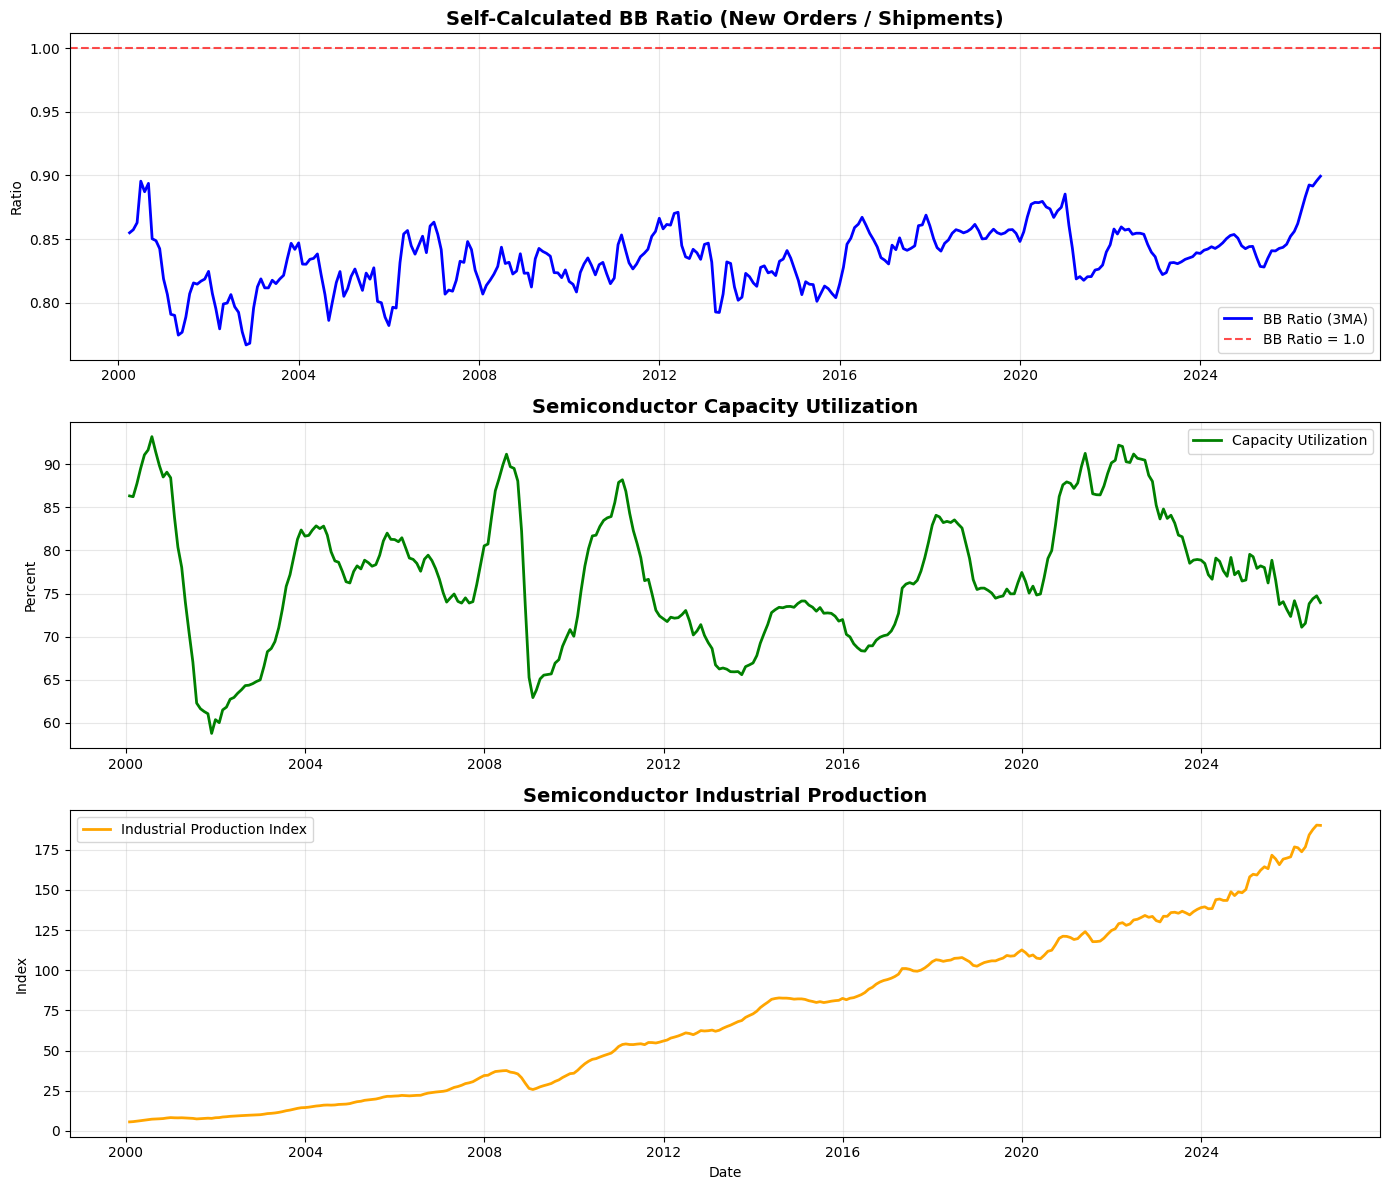


최근 데이터:
alias       capacity_utilization  industrial_production  new_orders  ppi_semiconductor  shipments  bb_ratio  bb_ratio_3ma  industrial_production_yoy_growth
period_end                                                                                                                                                 
2025-09-30               73.7232               165.6670     26803.0             59.754    31635.0  0.847258      0.842707                          0.131454
2025-10-31               74.0524               169.1163     26863.0             60.114    31713.0  0.847066      0.843570                          0.137203
2025-11-30               73.1444               169.7424     27015.0             60.857    32021.0  0.843665      0.845996                          0.145367
2025-12-31               72.3377               170.5402     27945.0             61.052    32273.0  0.865894      0.852208                          0.135213
2026-01-31               74.1644               176.7104

In [35]:
df = load_fred_wide(group="semiconductor_cycle", start=OBS_START)

# BB ratio 계산 (파생값은 DB에 저장하지 않고 읽을 때 계산)
df["bb_ratio"] = df["new_orders"] / df["shipments"]
df["bb_ratio_3ma"] = df["bb_ratio"].rolling(window=3).mean()
df["industrial_production_yoy_growth"] = df["industrial_production"].pct_change(12)

print("데이터 요약:")
print(df.describe())

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(df.index, df["bb_ratio_3ma"], label="BB Ratio (3MA)", linewidth=2, color="blue")
axes[0].axhline(y=1.0, color="r", linestyle="--", label="BB Ratio = 1.0", alpha=0.7)
axes[0].set_title("Self-Calculated BB Ratio (New Orders / Shipments)", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Ratio")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df.index, df["capacity_utilization"], label="Capacity Utilization", linewidth=2, color="green")
axes[1].set_title("Semiconductor Capacity Utilization", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Percent")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(df.index, df["industrial_production"], label="Industrial Production Index", linewidth=2, color="orange")
axes[2].set_title("Semiconductor Industrial Production", fontsize=14, fontweight="bold")
axes[2].set_ylabel("Index")
axes[2].set_xlabel("Date")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fred_semiconductor_indicators.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n최근 데이터:")
print(df.tail(12))

<AxesSubplot: title={'center': 'Semiconductor IP YoY'}, xlabel='period_end'>

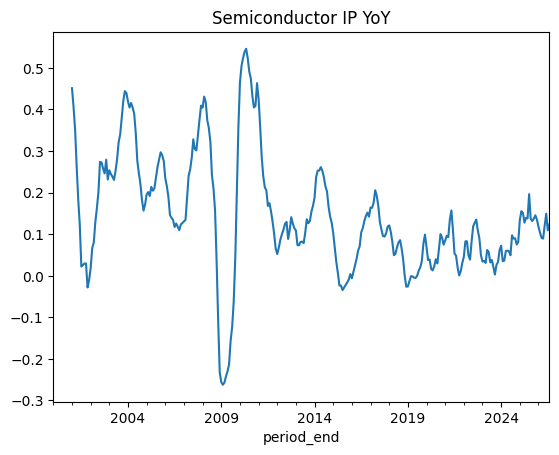

In [36]:
df["industrial_production_yoy_growth"].plot(title="Semiconductor IP YoY")